[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


100%|██████████| 16.3M/16.3M [00:02<00:00, 7.85MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5
Using CSV: /root/.cache/kagglehub/datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5/1429_1.csv

First 5 Rows:
                     id                                               name  \
0  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
1  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
2  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
3  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
4  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   

        asins   brand                                         categories  \
0  B01AHB9CN2  Amazon  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
1  B01AHB9CN2  Amazon  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
2  B01AHB9CN2  Amazon  Electronics,iPad & Tablets,All Tablets,Fire Ta...

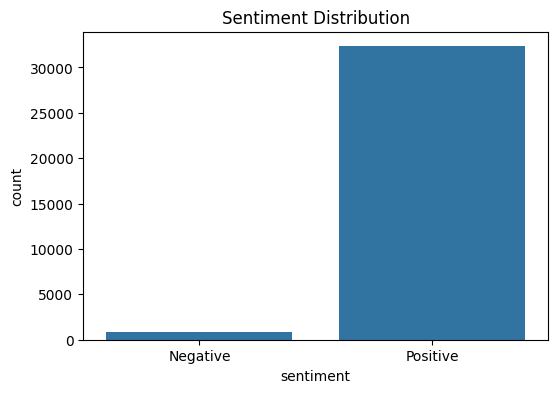


Preprocessing Text...

Accuracy: 97.74 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.09      0.16       162
           1       0.98      1.00      0.99      6464

    accuracy                           0.98      6626
   macro avg       0.93      0.54      0.57      6626
weighted avg       0.98      0.98      0.97      6626


Confusion Matrix:
[[  14  148]
 [   2 6462]]


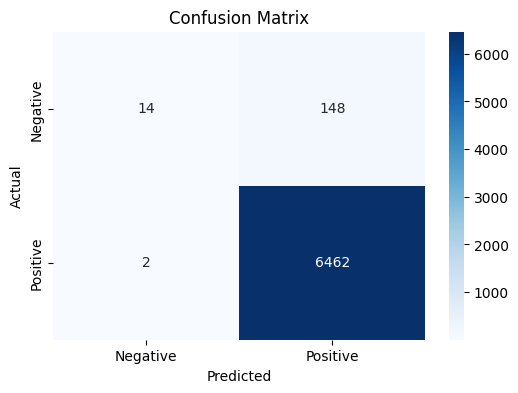


Sample Predictions:
Review: product amaz work perfectli
Sentiment: Positive

Review: worst purchas ever total disappoint
Sentiment: Positive

Review: good qualiti worth money
Sentiment: Positive

Review: bad product poor servic
Sentiment: Positive



In [1]:
# ============================================================
# SENTIMENT ANALYSIS USING NLP
# Amazon Product Reviews Dataset
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# DOWNLOAD NLTK DATA
# ============================================================

nltk.download('stopwords')

# ============================================================
# DOWNLOAD DATASET FROM KAGGLE
# ============================================================

path = kagglehub.dataset_download(
    "datafiniti/consumer-reviews-of-amazon-products"
)

print("Dataset Path:", path)

# ============================================================
# FIND CSV FILE
# ============================================================

csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

if len(csv_files) == 0:
    raise Exception("No CSV file found!")

csv_path = csv_files[0]

print("Using CSV:", csv_path)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(csv_path, low_memory=False)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

# ============================================================
# SELECT REQUIRED COLUMNS
# ============================================================

df = df[['reviews.text', 'reviews.rating']]

df.columns = ['review', 'rating']

# Remove missing values
df.dropna(inplace=True)

# ============================================================
# CREATE SENTIMENT LABELS
# ============================================================

# Remove neutral reviews (rating = 3)
df = df[df['rating'] != 3]

# Positive = 1, Negative = 0
df['sentiment'] = df['rating'].apply(
    lambda x: 1 if x >= 4 else 0
)

# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xticks([0, 1], ['Negative', 'Positive'])

plt.show()

# ============================================================
# TEXT PREPROCESSING
# ============================================================

ps = PorterStemmer()

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        ps.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("\nPreprocessing Text...")

df['review'] = df['review'].apply(preprocess_text)

# ============================================================
# FEATURE EXTRACTION (TF-IDF)
# ============================================================

X = df['review']
y = df['sentiment']

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# MODEL TRAINING
# ============================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

sample_reviews = [
    "This product is amazing and works perfectly.",
    "Worst purchase ever. Totally disappointed.",
    "Good quality and worth the money.",
    "Very bad product and poor service."
]

sample_reviews = [
    preprocess_text(review)
    for review in sample_reviews
]

sample_vectors = vectorizer.transform(sample_reviews)

predictions = model.predict(sample_vectors)

print("\nSample Predictions:")

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment}\n")
